In [1]:
"""
NexaCore Enterprise Intelligence Platform
Stage 7 — EDA & Statistical Modeling
Notebook 01: Executive & Business KPI Analysis

Business Objective:
    Understand the overall health of the NexaCore business across
    revenue, customers, products, operations, and support —
    and surface the key patterns that justify the downstream ML work.

Audience: Executive / Business stakeholder
Analyst role: Data Analyst
"""

'\nNexaCore Enterprise Intelligence Platform\nStage 7 — EDA & Statistical Modeling\nNotebook 01: Executive & Business KPI Analysis\n\nBusiness Objective:\n    Understand the overall health of the NexaCore business across\n    revenue, customers, products, operations, and support —\n    and surface the key patterns that justify the downstream ML work.\n\nAudience: Executive / Business stakeholder\nAnalyst role: Data Analyst\n'

# NexaCore — Executive & Business KPI Analysis

**Purpose:** End-to-end business health review using the Gold-layer data.
This notebook answers the question: *What does the business look like today,
and what are the patterns that a Data Scientist should investigate next?*

---
### Dataset Limitations (acknowledged upfront)
| Limitation | Impact on this analysis |
|---|---|
| Inventory: 400 point-in-time records (single snapshot date 2026-06-30) | Inventory analysis is cross-sectional only — no trend available |
| SCD2: Version 1 only | Cannot analyse customer attribute changes over time |
| Maintenance events: only 3 records | Equipment section limited to telemetry signals |

## 0. Setup

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from data_science.config import PALETTE, CATEGORICAL_PALETTE, CONTROL_TOTALS, DATASET_LIMITATIONS
from data_science.db import (
    load_order_items, load_orders, load_support_tickets,
    load_inventory_snapshot, load_telemetry_features, read_sql
)
from data_science.plotting import (
    save_figure, plot_bar, plot_time_series,
    plot_lorenz_curve, plot_boxplot_by_group,
    plot_correlation_heatmap
)

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)

print("✓ Libraries loaded")
print(f"  Canonical Net Revenue:  ${CONTROL_TOTALS['net_revenue']:>16,.2f}")
print(f"  Canonical Total Orders: {CONTROL_TOTALS['total_orders']:>16,}")

✓ Libraries loaded
  Canonical Net Revenue:  $   77,237,960.93
  Canonical Total Orders:           10,000


---
## 1. Business Question

*How is NexaCore performing across its five core operational domains —
revenue, customers, products, inventory, and machine operations?*

Sub-questions:
1. What is the revenue trend and is it growing?
2. Which products drive the most value, and which underperform?
3. How concentrated is revenue across customers (Pareto principle)?
4. What is the state of customer satisfaction, and does it vary by segment?
5. How healthy is inventory — which warehouses/categories are at risk?
6. What is the machine fleet's operational health?

## 2. Data Loading & Understanding

In [3]:
print("Loading Gold-layer fact tables...")
df_items    = load_order_items()
df_orders   = load_orders()
df_tickets  = load_support_tickets()
df_inv      = load_inventory_snapshot()
df_telem    = load_telemetry_features()

print(f"\n  fact_order_items:       {len(df_items):>8,} rows")
print(f"  fact_orders:            {len(df_orders):>8,} rows")
print(f"  fact_support_tickets:   {len(df_tickets):>8,} rows")
print(f"  fact_inventory_snapshot:{len(df_inv):>8,} rows")
print(f"  fact_machine_telemetry: {len(df_telem):>8,} rows")

Loading Gold-layer fact tables...



  fact_order_items:         35,193 rows
  fact_orders:              10,000 rows
  fact_support_tickets:      2,500 rows
  fact_inventory_snapshot:     400 rows
  fact_machine_telemetry:  100,000 rows


## 3. Data Quality Assessment

In [4]:
from data_science.feature_profile import profile_dataframe, flag_data_quality_issues

print("=== ORDER ITEMS — Data Quality ===")
profile_items = profile_dataframe(df_items[["quantity","unit_price","discount_amount","gross_revenue","net_revenue","gross_profit_margin"]])
issues_items  = flag_data_quality_issues(profile_items)
print(f"  Columns profiled: {len(profile_items)}")
print(f"  DQ issues found:  {len(issues_items)}")
if len(issues_items):
    display(issues_items)

print("\n=== SUPPORT TICKETS — Data Quality ===")
profile_tickets = profile_dataframe(df_tickets[["csat_score"]])
issues_tickets  = flag_data_quality_issues(profile_tickets)
print(f"  DQ issues found: {len(issues_tickets)}")
if len(issues_tickets):
    display(issues_tickets)

=== ORDER ITEMS — Data Quality ===
  Columns profiled: 6
  DQ issues found:  2


,column,dtype,issues
0,discount_amount,float64,OUTLIERS: 6.1% IQR outliers
1,gross_profit_margin,float64,OUTLIERS: 5.3% IQR outliers



=== SUPPORT TICKETS — Data Quality ===
  DQ issues found: 1


,column,dtype,issues
0,csat_score,float64,HIGH MISSING: 45.6%


## 4. Univariate Revenue Analysis

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_revenue_trend.png


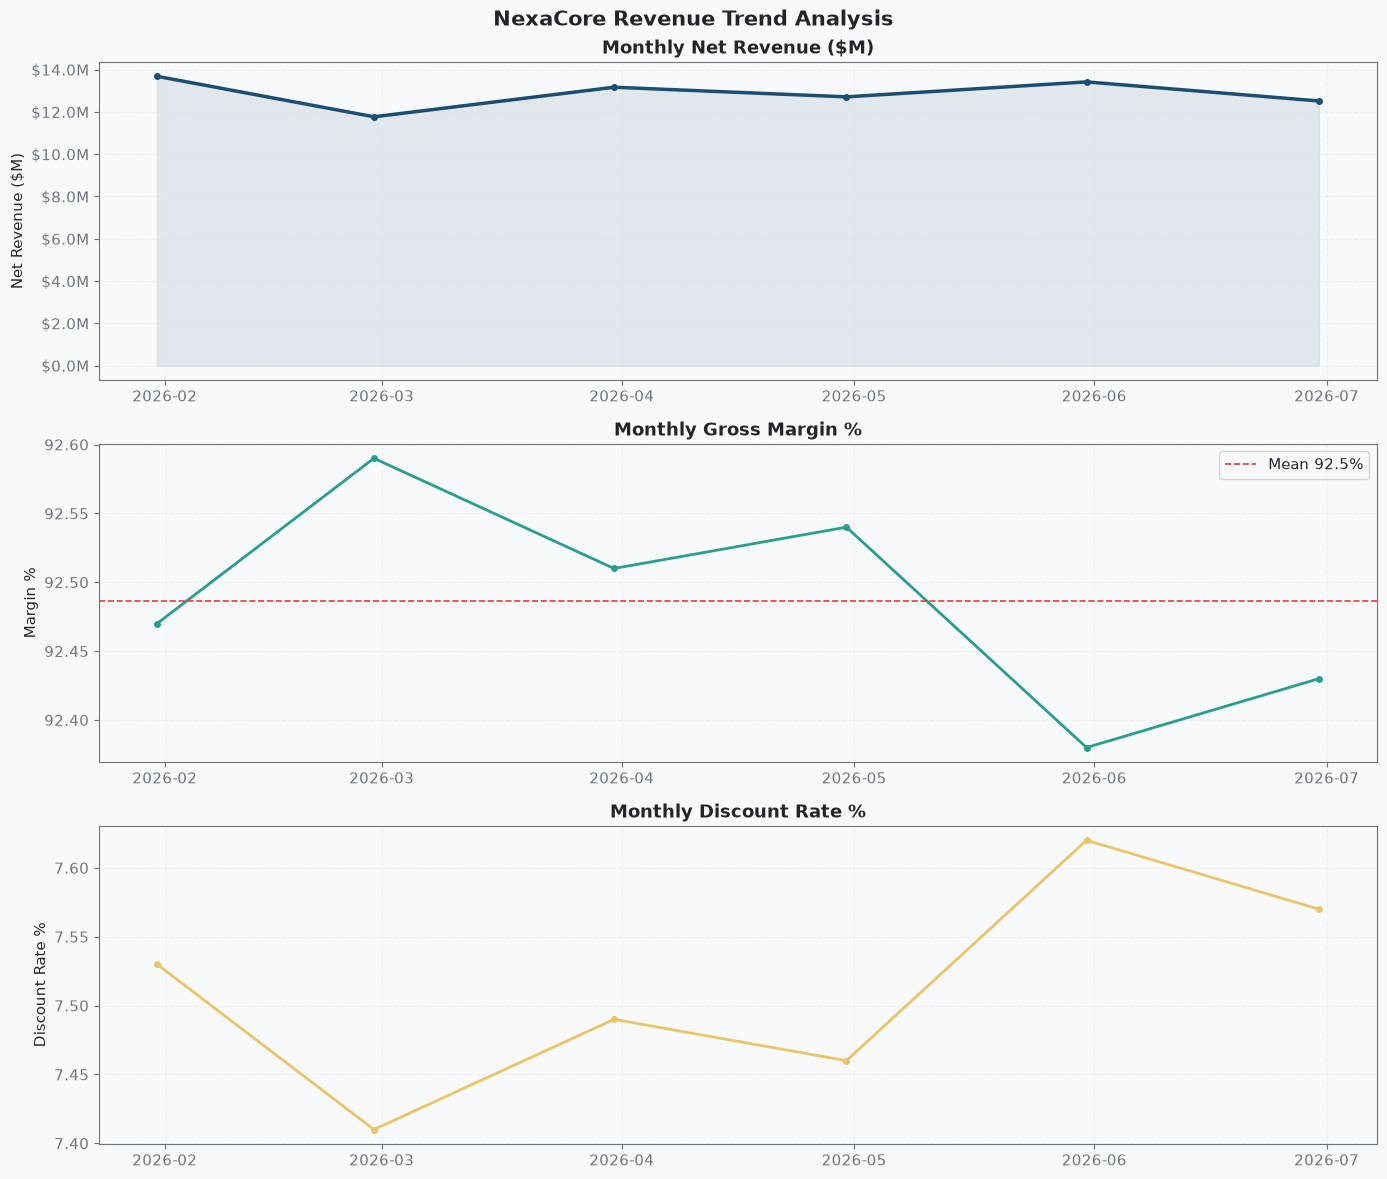


📊 Revenue Summary:
  Total Net Revenue: $  77,237,960.93  (canonical: $77,237,960.93)
  Monthly avg revenue: $12,872,993.49
  Peak month: 2026-01  ($13,678,895.93)
  Avg gross margin: 92.49%
  Avg discount rate: 7.51%


In [5]:
# ── 4.1 Monthly Revenue Trend ──────────────────────────────────────────────
df_items["order_date"] = pd.to_datetime(df_items["order_date"])

monthly = (
    df_items.set_index("order_date")
    .resample("ME")[["gross_revenue", "net_revenue", "discount_amount"]]
    .sum()
    .reset_index()
)
monthly["gross_margin_pct"] = (monthly["net_revenue"] / monthly["gross_revenue"] * 100).round(2)
monthly["discount_rate_pct"] = (monthly["discount_amount"] / monthly["gross_revenue"] * 100).round(2)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(monthly["order_date"], monthly["net_revenue"] / 1e6,
             color=PALETTE["primary"], linewidth=2.5, marker="o", markersize=4)
axes[0].fill_between(monthly["order_date"], monthly["net_revenue"] / 1e6,
                     alpha=0.1, color=PALETTE["primary"])
axes[0].set_title("Monthly Net Revenue ($M)")
axes[0].set_ylabel("Net Revenue ($M)")
axes[0].grid(True, alpha=0.4)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fM"))

axes[1].plot(monthly["order_date"], monthly["gross_margin_pct"],
             color=PALETTE["success"], linewidth=2, marker="o", markersize=4)
axes[1].axhline(monthly["gross_margin_pct"].mean(), color=PALETTE["danger"],
                linestyle="--", linewidth=1.2, label=f"Mean {monthly['gross_margin_pct'].mean():.1f}%")
axes[1].set_title("Monthly Gross Margin %")
axes[1].set_ylabel("Margin %")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

axes[2].plot(monthly["order_date"], monthly["discount_rate_pct"],
             color=PALETTE["warning"], linewidth=2, marker="o", markersize=4)
axes[2].set_title("Monthly Discount Rate %")
axes[2].set_ylabel("Discount Rate %")
axes[2].grid(True, alpha=0.4)

fig.suptitle("NexaCore Revenue Trend Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
save_figure(fig, "01_revenue_trend")
plt.show()

# Print summary stats
print("\n📊 Revenue Summary:")
print(f"  Total Net Revenue: ${df_items['net_revenue'].sum():>15,.2f}  (canonical: ${CONTROL_TOTALS['net_revenue']:,.2f})")
print(f"  Monthly avg revenue: ${monthly['net_revenue'].mean():>12,.2f}")
print(f"  Peak month: {monthly.loc[monthly['net_revenue'].idxmax(), 'order_date'].strftime('%Y-%m')}  (${monthly['net_revenue'].max():,.2f})")
print(f"  Avg gross margin: {monthly['gross_margin_pct'].mean():.2f}%")
print(f"  Avg discount rate: {monthly['discount_rate_pct'].mean():.2f}%")

## 5. Bivariate / Multivariate Analysis

### 5.1 Product Performance

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_product_performance.png


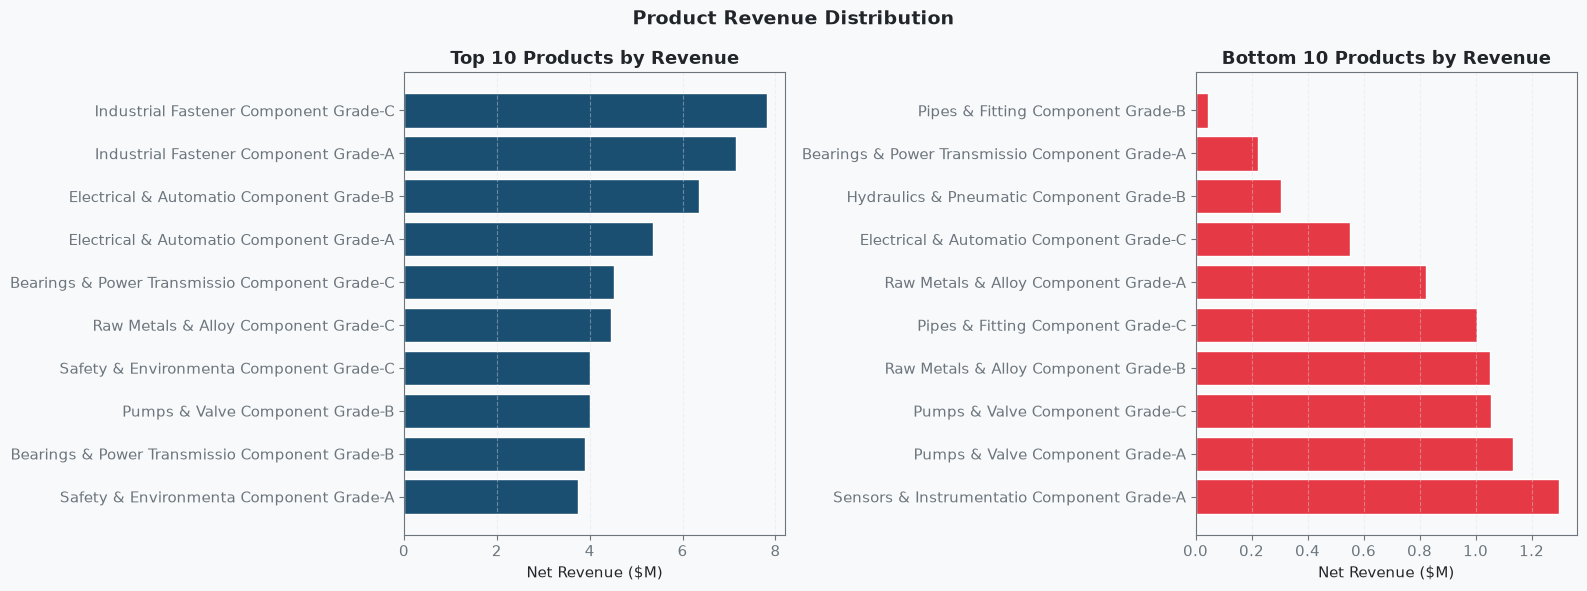


📊 Product Stats:
  Total products: 28
  Top product revenue share: 10.13%
  Top 10 products revenue share: 66.45%

📊 Category Performance:


,category_name,total_revenue,total_units,avg_margin,revenue_pct
0,Industrial Fasteners,"16,512,951.67",33730,"1,083.29",21.38
1,Electrical & Automation,"12,270,137.81",27362,766.49,15.89
2,Safety & Environmental,"9,641,857.76",25901,668.83,12.48
3,Bearings & Power Transmission,"8,652,145.86",24717,727.42,11.20
4,Sensors & Instrumentation,"6,583,230.26",13015,"1,088.59",8.52
5,Raw Metals & Alloys,"6,325,241.73",20062,494.91,8.19
6,Pumps & Valves,"6,188,418.29",12665,"1,074.22",8.01
7,Pipes & Fittings,"4,112,929.90",15685,595.18,5.33
8,Hydraulics & Pneumatics,"3,668,060.85",9165,691.73,4.75
9,Cutting Tools & Abrasives,"3,282,986.80",10273,783.63,4.25


In [6]:
product_perf = (
    df_items.groupby("product_name")
    .agg(
        total_revenue=("net_revenue", "sum"),
        total_units=("quantity", "sum"),
        avg_margin=("gross_profit_margin", "mean"),
        order_count=("order_id", "nunique"),
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)
product_perf["revenue_pct"] = (product_perf["total_revenue"] / product_perf["total_revenue"].sum() * 100).round(2)

# Top 10 by revenue
top10 = product_perf.head(10)
bot10 = product_perf.tail(10).sort_values("total_revenue")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
axes[0].barh(top10["product_name"], top10["total_revenue"] / 1e6,
             color=PALETTE["primary"], edgecolor="white")
axes[0].set_xlabel("Net Revenue ($M)")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.4, axis="x")

# Bottom 10
axes[1].barh(bot10["product_name"], bot10["total_revenue"] / 1e6,
             color=PALETTE["danger"], edgecolor="white")
axes[1].set_xlabel("Net Revenue ($M)")
axes[1].set_title("Bottom 10 Products by Revenue")
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.4, axis="x")

fig.suptitle("Product Revenue Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "01_product_performance")
plt.show()

print("\n📊 Product Stats:")
print(f"  Total products: {product_perf['product_name'].nunique()}")
print(f"  Top product revenue share: {product_perf.iloc[0]['revenue_pct']:.2f}%")
print(f"  Top 10 products revenue share: {product_perf.head(10)['revenue_pct'].sum():.2f}%")

# Category level
cat_perf = (
    df_items.groupby("category_name")
    .agg(total_revenue=("net_revenue","sum"), total_units=("quantity","sum"),
         avg_margin=("gross_profit_margin","mean"))
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)
cat_perf["revenue_pct"] = (cat_perf["total_revenue"] / cat_perf["total_revenue"].sum() * 100).round(2)
print("\n📊 Category Performance:")
display(cat_perf)

### 5.2 Customer Revenue Concentration (Lorenz / Pareto)

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_lorenz_curve.png


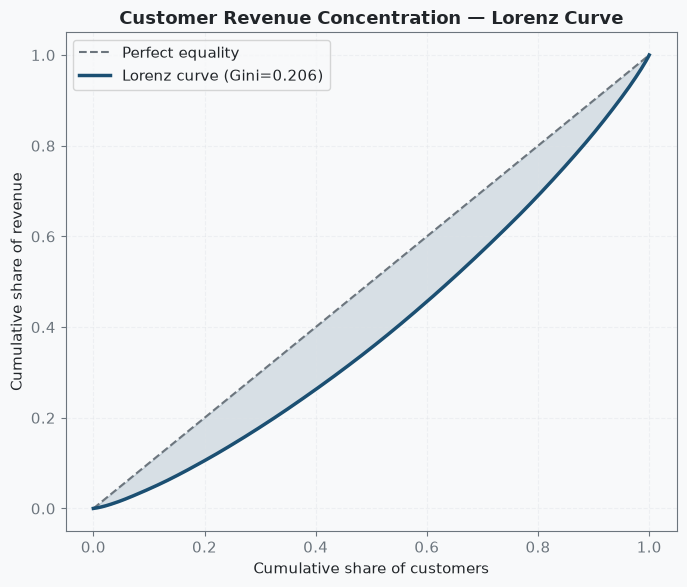


📊 Customer Concentration:
  Gini coefficient: 0.2060  (0=perfect equality, 1=extreme concentration)
  Top 11.9% of customers generate 80% of revenue (Pareto ratio)
  Interpretation: MODERATE concentration

📊 Revenue by Customer Segment:
  Small & Medium Business $45,619,945.79  (59.1%)
  Mid-Market Corporate $24,693,058.02  (32.0%)
  Enterprise Clients   $6,924,957.12  (9.0%)


In [7]:
customer_rev = (
    df_orders.groupby("customer_id")["net_amount"]
    .sum()
    .sort_values()
    .reset_index()
)

fig_lorenz, gini = plot_lorenz_curve(
    customer_rev["net_amount"],
    title="Customer Revenue Concentration — Lorenz Curve",
    figname="01_lorenz_curve",
)
plt.show()

# Pareto: what % of customers generate 80% of revenue?
total_rev = customer_rev["net_amount"].sum()
cumrev    = customer_rev["net_amount"].cumsum() / total_rev
pareto_idx = (cumrev >= 0.80).idxmax()
pareto_pct = pareto_idx / len(customer_rev) * 100

print(f"\n📊 Customer Concentration:")
print(f"  Gini coefficient: {gini:.4f}  (0=perfect equality, 1=extreme concentration)")
print(f"  Top {100-pareto_pct:.1f}% of customers generate 80% of revenue (Pareto ratio)")
print(f"  Interpretation: {'HIGH concentration — top customers critical' if gini > 0.5 else 'MODERATE concentration'}")

# Revenue by segment
seg_rev = df_orders.groupby("customer_segment")["net_amount"].sum().sort_values(ascending=False)
print("\n📊 Revenue by Customer Segment:")
for seg, rev in seg_rev.items():
    print(f"  {seg:<20} ${rev:>12,.2f}  ({rev/total_rev*100:.1f}%)")

### 5.3 Sales Channel & Payment Method Analysis

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_channel_analysis.png


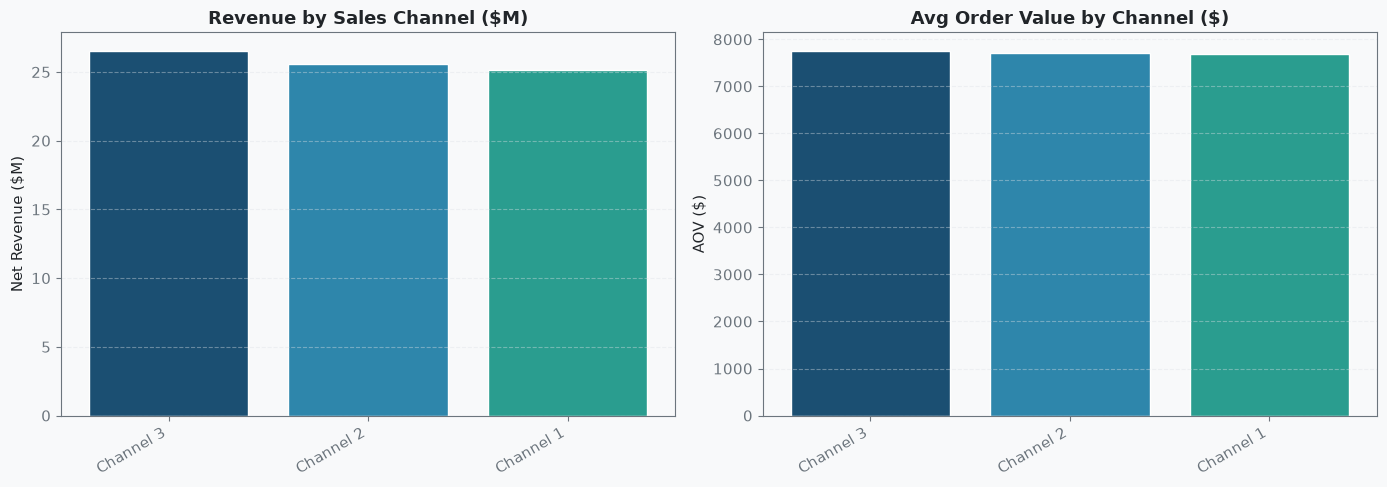

,channel_name,orders,total_revenue,avg_order_value
0,Channel 3,3422,"26,556,445.82","7,760.50"
1,Channel 2,3311,"25,558,766.40","7,719.35"
2,Channel 1,3267,"25,122,748.71","7,689.85"


In [8]:
df_orders["channel_name"] = "Channel " + df_orders["channel_id"].astype(str)
channel_stats = (
    df_orders.groupby("channel_name")
    .agg(
        orders=("order_id","count"),
        total_revenue=("net_amount","sum"),
        avg_order_value=("net_amount","mean"),
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(channel_stats["channel_name"], channel_stats["total_revenue"]/1e6,
            color=CATEGORICAL_PALETTE[:len(channel_stats)], edgecolor="white")
axes[0].set_title("Revenue by Sales Channel ($M)")
axes[0].set_ylabel("Net Revenue ($M)")
axes[0].grid(True, alpha=0.4, axis="y")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

axes[1].bar(channel_stats["channel_name"], channel_stats["avg_order_value"],
            color=CATEGORICAL_PALETTE[:len(channel_stats)], edgecolor="white")
axes[1].set_title("Avg Order Value by Channel ($)")
axes[1].set_ylabel("AOV ($)")
axes[1].grid(True, alpha=0.4, axis="y")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
save_figure(fig, "01_channel_analysis")
plt.show()
display(channel_stats)

### 5.4 CSAT Distribution & Trend

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_csat_analysis.png


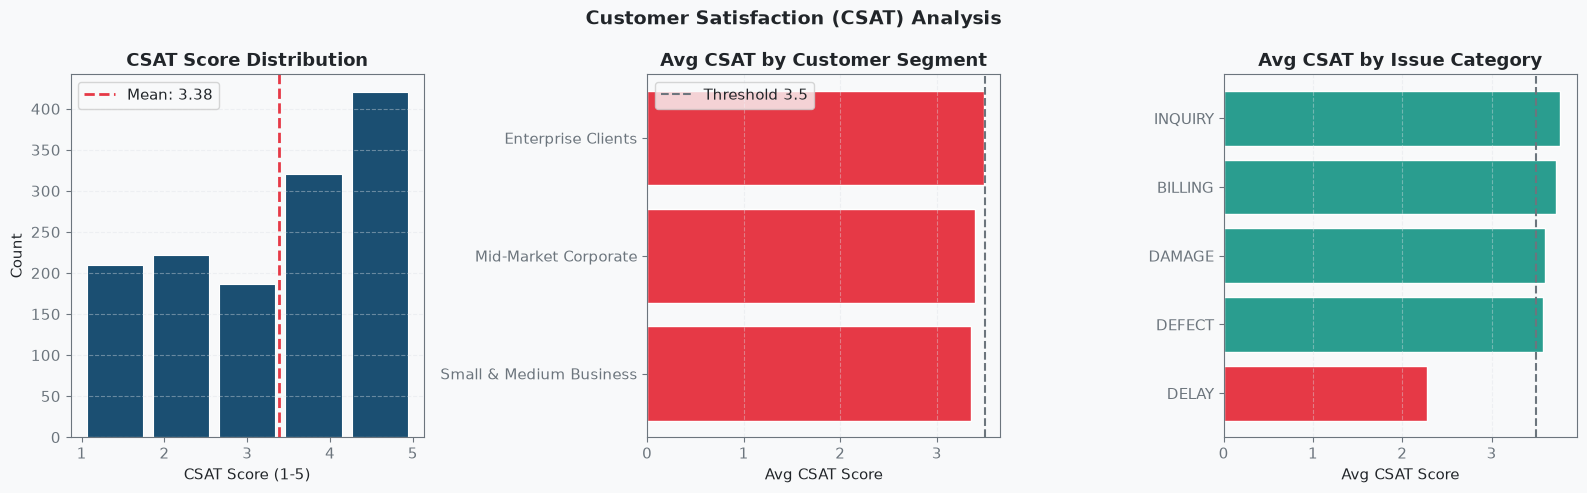


📊 CSAT Summary:
  Overall avg CSAT: 3.3824  (canonical: 3.38)
  Total tickets: 2,500  (canonical: 2,500)
  Below 3.0 CSAT: 432 tickets (17.3%)


In [9]:
df_tickets["ticket_date"] = pd.to_datetime(df_tickets["ticket_date"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CSAT distribution
axes[0].hist(df_tickets["csat_score"].dropna(), bins=5, color=PALETTE["primary"],
             edgecolor="white", linewidth=0.8, rwidth=0.85)
axes[0].axvline(df_tickets["csat_score"].mean(), color=PALETTE["danger"],
                linestyle="--", linewidth=2, label=f"Mean: {df_tickets['csat_score'].mean():.2f}")
axes[0].set_title("CSAT Score Distribution")
axes[0].set_xlabel("CSAT Score (1-5)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.4, axis="y")

# CSAT by segment
seg_csat = df_tickets.groupby("customer_segment")["csat_score"].mean().sort_values()
colors = [PALETTE["danger"] if v < 3.5 else PALETTE["success"] for v in seg_csat.values]
axes[1].barh(seg_csat.index, seg_csat.values, color=colors, edgecolor="white")
axes[1].axvline(3.5, color=PALETTE["neutral"], linestyle="--", linewidth=1.5,
                label="Threshold 3.5")
axes[1].set_title("Avg CSAT by Customer Segment")
axes[1].set_xlabel("Avg CSAT Score")
axes[1].legend()
axes[1].grid(True, alpha=0.4, axis="x")

# CSAT by issue category
cat_csat = df_tickets.groupby("issue_category")["csat_score"].mean().sort_values()
colors2 = [PALETTE["danger"] if v < 3.5 else PALETTE["success"] for v in cat_csat.values]
axes[2].barh(cat_csat.index, cat_csat.values, color=colors2, edgecolor="white")
axes[2].axvline(3.5, color=PALETTE["neutral"], linestyle="--", linewidth=1.5)
axes[2].set_title("Avg CSAT by Issue Category")
axes[2].set_xlabel("Avg CSAT Score")
axes[2].grid(True, alpha=0.4, axis="x")

fig.suptitle("Customer Satisfaction (CSAT) Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "01_csat_analysis")
plt.show()

print(f"\n📊 CSAT Summary:")
print(f"  Overall avg CSAT: {df_tickets['csat_score'].mean():.4f}  (canonical: {CONTROL_TOTALS['avg_csat']})")
print(f"  Total tickets: {len(df_tickets):,}  (canonical: {CONTROL_TOTALS['support_tickets']:,})")
print(f"  Below 3.0 CSAT: {(df_tickets['csat_score'] < 3.0).sum():,} tickets ({(df_tickets['csat_score'] < 3.0).mean()*100:.1f}%)")

### 5.5 Inventory Health Overview


[NOTE] fact_inventory_snapshot contains 400 point-in-time records on a single snapshot date (2026-06-30). This is NOT a daily time-series. Stockout risk analysis is cross-sectional, not longitudinal.



  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_inventory_health.png


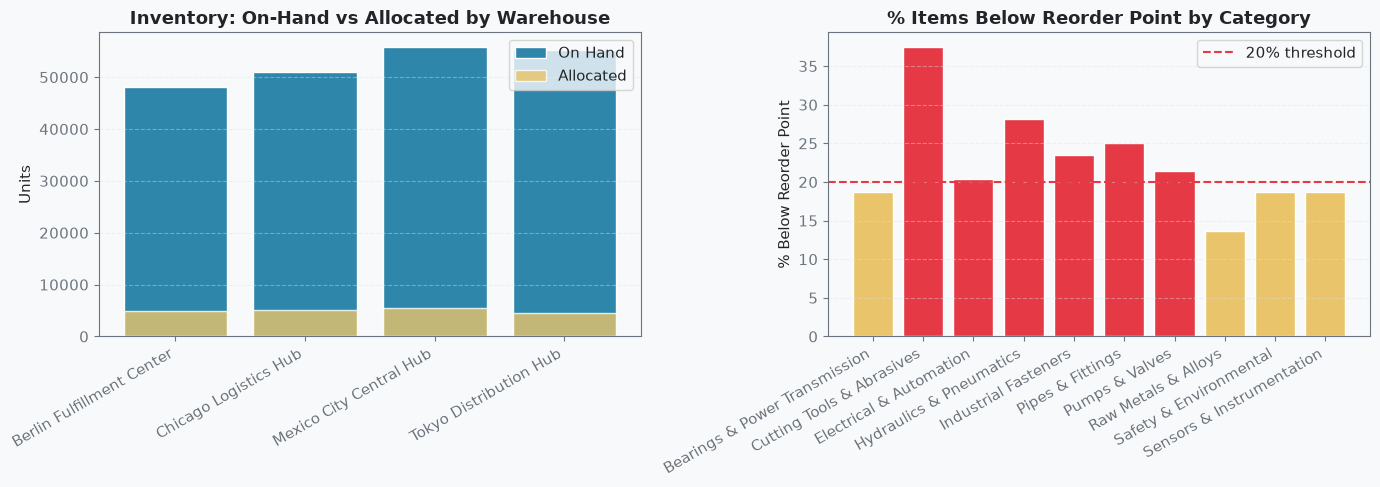


📊 Inventory Summary:
  Total On Hand: 210,174  (canonical: 210,174)
  Items below reorder: 85  (canonical: 85)


,warehouse_name,total_on_hand,total_allocated,total_available,items_below_reorder,total_items,below_reorder_pct,utilization_pct
0,Berlin Fulfillment Center,48107,4975,43132,23,100,23.00,10.34
1,Chicago Logistics Hub,50986,5083,45903,21,100,21.00,9.97
2,Mexico City Central Hub,55853,5493,50360,22,100,22.00,9.83
3,Tokyo Distribution Hub,55228,4514,50714,19,100,19.00,8.17


In [10]:
print(f"\n[NOTE] {DATASET_LIMITATIONS['inventory_grain']}")
print()

inv_by_wh = (
    df_inv.groupby("warehouse_name")
    .agg(
        total_on_hand=("quantity_on_hand","sum"),
        total_allocated=("quantity_allocated","sum"),
        total_available=("quantity_available","sum"),
        items_below_reorder=("is_below_reorder_point","sum"),
        total_items=("inventory_id","count"),
    )
    .reset_index()
)
inv_by_wh["below_reorder_pct"] = (inv_by_wh["items_below_reorder"] / inv_by_wh["total_items"] * 100).round(2)
inv_by_wh["utilization_pct"]   = (inv_by_wh["total_allocated"] / inv_by_wh["total_on_hand"] * 100).round(2)

inv_by_cat = (
    df_inv.groupby("category_name")
    .agg(
        total_on_hand=("quantity_on_hand","sum"),
        items_below_reorder=("is_below_reorder_point","sum"),
        total_items=("inventory_id","count"),
    )
    .reset_index()
)
inv_by_cat["below_reorder_pct"] = (inv_by_cat["items_below_reorder"] / inv_by_cat["total_items"] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(inv_by_wh["warehouse_name"], inv_by_wh["total_on_hand"],
            color=PALETTE["secondary"], edgecolor="white", label="On Hand")
axes[0].bar(inv_by_wh["warehouse_name"], inv_by_wh["total_allocated"],
            color=PALETTE["warning"], edgecolor="white", alpha=0.8, label="Allocated")
axes[0].set_title("Inventory: On-Hand vs Allocated by Warehouse")
axes[0].set_ylabel("Units")
axes[0].legend()
axes[0].grid(True, alpha=0.4, axis="y")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

axes[1].bar(inv_by_cat["category_name"], inv_by_cat["below_reorder_pct"],
            color=[PALETTE["danger"] if v > 20 else PALETTE["warning"] if v > 10 else PALETTE["success"]
                   for v in inv_by_cat["below_reorder_pct"]],
            edgecolor="white")
axes[1].axhline(20, color=PALETTE["danger"], linestyle="--", linewidth=1.5, label="20% threshold")
axes[1].set_title("% Items Below Reorder Point by Category")
axes[1].set_ylabel("% Below Reorder Point")
axes[1].legend()
axes[1].grid(True, alpha=0.4, axis="y")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
save_figure(fig, "01_inventory_health")
plt.show()

print("\n📊 Inventory Summary:")
print(f"  Total On Hand: {df_inv['quantity_on_hand'].sum():,}  (canonical: {CONTROL_TOTALS['inventory_on_hand']:,})")
print(f"  Items below reorder: {df_inv['is_below_reorder_point'].sum()}  (canonical: {CONTROL_TOTALS['low_stock_items']})")
display(inv_by_wh)

### 5.6 Machine Fleet Overview


📊 Fleet Summary (50 machines, 100,000 telemetry records):
  Avg temperature: 65.37°C  (canonical: 100,000 records)
  Temp anomaly flag rate: 0.90%
  Vibration anomaly flag rate: 0.90%

📊 By Machine Type:


,machine_type,machines,avg_temp,avg_vibration,anomaly_rate
0,CNC_LATHE,9,64.98,1.20,0.00
1,CONVEYOR_SYSTEM,9,64.98,1.20,0.00
2,HYDRAULIC_PRESS,10,65.42,1.24,1.01
3,INJECTION_MOLDER,11,65.93,1.29,2.25
4,ROBOTIC_ARM,11,65.39,1.24,0.94


  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\01_fleet_overview.png


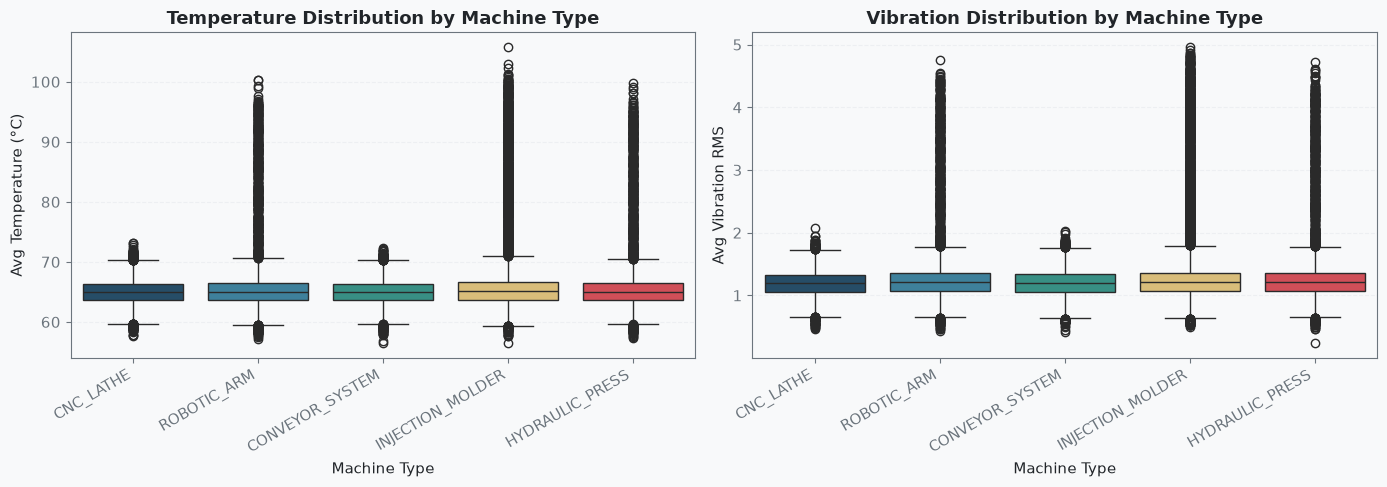

In [11]:
fleet_summary = (
    df_telem.groupby("machine_id")
    .agg(
        avg_temp=("avg_temperature_c","mean"),
        max_temp=("max_temperature_c","max"),
        avg_vibration=("avg_vibration_rms","mean"),
        avg_power=("avg_power_kw","mean"),
        anomaly_count=("temperature_anomaly_flag","sum"),
        total_events=("event_count","count"),
    )
    .reset_index()
)
fleet_summary["anomaly_rate"] = (fleet_summary["anomaly_count"] / fleet_summary["total_events"] * 100).round(2)

print(f"\n📊 Fleet Summary ({df_telem['machine_id'].nunique()} machines, {len(df_telem):,} telemetry records):")
print(f"  Avg temperature: {df_telem['avg_temperature_c'].mean():.2f}°C  (canonical: {CONTROL_TOTALS['telemetry_records']:,} records)")
print(f"  Temp anomaly flag rate: {df_telem['temperature_anomaly_flag'].mean()*100:.2f}%")
print(f"  Vibration anomaly flag rate: {df_telem['vibration_anomaly_flag'].mean()*100:.2f}%")

by_type = df_telem.groupby("machine_type").agg(
    machines=("machine_id","nunique"),
    avg_temp=("avg_temperature_c","mean"),
    avg_vibration=("avg_vibration_rms","mean"),
    anomaly_rate=("temperature_anomaly_flag","mean"),
).reset_index()
by_type["anomaly_rate"] = (by_type["anomaly_rate"] * 100).round(2)
print("\n📊 By Machine Type:")
display(by_type)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_telem, x="machine_type", y="avg_temperature_c",
            palette=CATEGORICAL_PALETTE[:df_telem["machine_type"].nunique()], ax=axes[0])
axes[0].set_title("Temperature Distribution by Machine Type")
axes[0].set_xlabel("Machine Type")
axes[0].set_ylabel("Avg Temperature (°C)")
axes[0].grid(True, alpha=0.4, axis="y")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.boxplot(data=df_telem, x="machine_type", y="avg_vibration_rms",
            palette=CATEGORICAL_PALETTE[:df_telem["machine_type"].nunique()], ax=axes[1])
axes[1].set_title("Vibration Distribution by Machine Type")
axes[1].set_xlabel("Machine Type")
axes[1].set_ylabel("Avg Vibration RMS")
axes[1].grid(True, alpha=0.4, axis="y")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
save_figure(fig, "01_fleet_overview")
plt.show()

## 6. Statistical Hypothesis Tests

In [12]:
from data_science.stats import ttest_independent, mannwhitney, chi_square, results_table
from scipy import stats as sp_stats

test_results = []

# H1: Do different customer segments have different AOV?
seg_aov = df_orders.groupby("customer_segment")["net_amount"].apply(list)
if len(seg_aov) >= 2:
    segs = list(seg_aov.index)
    r = ttest_independent(
        pd.Series(seg_aov.iloc[0]), pd.Series(seg_aov.iloc[1]),
        label_a=segs[0], label_b=segs[1]
    )
    test_results.append(r)
    print(f"\nH1 — AOV: {segs[0]} vs {segs[1]}")
    print(f"  Means: ${r['mean_a']:,.2f} vs ${r['mean_b']:,.2f}")
    print(f"  p={r['p_value']}  {r['significance']}  effect={r['effect_size']}")

# H2: Does discount rate affect CSAT? (Pearson correlation: discount_amount vs csat)
merged = df_orders.merge(
    df_tickets.groupby("customer_id")["csat_score"].mean().reset_index(),
    on="customer_id", how="inner"
)
r_corr, p_corr = sp_stats.pearsonr(merged["discount_amount"], merged["csat_score"])
test_results.append({
    "test": "Pearson correlation",
    "feature": "discount_amount vs csat_score",
    "r": round(r_corr, 4),
    "p_value": round(p_corr, 6),
    "significant": p_corr < 0.05,
    "significance": f"{'*' if p_corr < 0.05 else 'ns'} (p={p_corr:.4f})",
    "effect_size": abs(round(r_corr, 4)),
})
print(f"\nH2 — Discount vs CSAT: r={r_corr:.4f}  p={p_corr:.4f}  {'significant' if p_corr < 0.05 else 'not significant'}")

# H3: Do below-reorder items have lower available quantity vs adequate stock?
below = df_inv.loc[df_inv["is_below_reorder_point"], "quantity_available"]
above = df_inv.loc[~df_inv["is_below_reorder_point"], "quantity_available"]
r_mw = mannwhitney(below, above, label_a="Below Reorder", label_b="Above Reorder")
test_results.append(r_mw)
print(f"\nH3 — Inventory: Below vs Above Reorder Point (quantity_available)")
print(f"  Medians: {r_mw['median_a']:.0f} vs {r_mw['median_b']:.0f}")
print(f"  p={r_mw['p_value']}  {r_mw['significance']}  effect={r_mw['effect_size']}")


H1 — AOV: Enterprise Clients vs Mid-Market Corporate
  Means: $7,643.44 vs $7,748.06
  p=0.57146  ns  (not significant)  effect=negligible

H2 — Discount vs CSAT: r=nan  p=nan  not significant

H3 — Inventory: Below vs Above Reorder Point (quantity_available)
  Medians: 155 vs 585
  p=0.0  *** (p<0.001)  effect=medium


## 7. Business Interpretation

In [13]:
print("=" * 65)
print("  EXECUTIVE FINDINGS — NexaCore Business Health Review")
print("=" * 65)

net_rev = df_items["net_revenue"].sum()
gross_rev = df_items["gross_revenue"].sum()
margin_pct = net_rev / gross_rev * 100
discount_rate = df_items["discount_amount"].sum() / gross_rev * 100

print(f"""
REVENUE
  Net Revenue:     ${net_rev:>15,.2f}
  Gross Revenue:   ${gross_rev:>15,.2f}
  Gross Margin:    {margin_pct:.2f}%
  Discount Rate:   {discount_rate:.2f}%
  Total Orders:    {df_orders['order_id'].nunique():>10,}
  AOV (Net):       ${df_orders['net_amount'].mean():>12,.2f}

CUSTOMERS
  Total Customers: {df_orders['customer_id'].nunique():>10,}
  Gini Coefficient:{gini:>10.4f}   (revenue concentration)
  Avg CSAT:        {df_tickets['csat_score'].mean():>10.4f}

INVENTORY (snapshot 2026-06-30)
  Total On Hand:   {df_inv['quantity_on_hand'].sum():>10,} units
  Below Reorder:   {df_inv['is_below_reorder_point'].sum():>10} items ({df_inv['is_below_reorder_point'].mean()*100:.1f}%)

MACHINE FLEET
  Machines:        {df_telem['machine_id'].nunique():>10}
  Telemetry Events:{len(df_telem):>10,}
  Temp Anomalies:  {df_telem['temperature_anomaly_flag'].mean()*100:>9.2f}%
""")

  EXECUTIVE FINDINGS — NexaCore Business Health Review

REVENUE
  Net Revenue:     $  77,237,960.93
  Gross Revenue:   $  83,513,938.52
  Gross Margin:    92.49%
  Discount Rate:   7.51%
  Total Orders:        10,000
  AOV (Net):       $    7,723.80

CUSTOMERS
  Total Customers:      1,000
  Gini Coefficient:    0.2060   (revenue concentration)
  Avg CSAT:            3.3824

INVENTORY (snapshot 2026-06-30)
  Total On Hand:      210,174 units
  Below Reorder:           85 items (21.2%)

MACHINE FLEET
  Machines:                50
  Telemetry Events:   100,000
  Temp Anomalies:       0.90%



## 8. Feature Candidates for ML Stages

In [14]:
print("""
FEATURE CANDIDATES IDENTIFIED IN THIS ANALYSIS:
─────────────────────────────────────────────────────────────────
CHURN (Stage 8 — Classification):
  • days_since_last_order         (strong decay signal)
  • order_frequency_30d / 90d     (engagement trend)
  • avg_csat_score                (satisfaction deterioration)
  • total_support_tickets         (dissatisfaction proxy)
  • avg_order_value               (value tier)
  • customer_segment              (categorical risk profile)

DEMAND FORECASTING (Stage 8 — Time-series):
  • lag_7 / lag_14 (verified anti-leakage in Stage 4B)
  • rolling_avg_7d                (trend smoothing)
  • category_name                 (category-level patterns)
  • weekday / month               (seasonality components)

INVENTORY STOCKOUT (Stage 8 — Classification):
  • quantity_available            (direct signal)
  • reorder_point                 (threshold baseline)
  • quantity_allocated            (demand pressure)
  • warehouse_id                  (location risk)
  • category_name                 (category risk patterns)

MACHINE ANOMALY (Stage 8 — Unsupervised):
  • avg_temperature_c             (primary signal)
  • avg_vibration_rms             (primary signal)
  • avg_pressure_psi              (secondary signal)
  • avg_power_kw                  (secondary signal)
  • machine_type                  (baseline per type)
  • rolling deviations            (drift detection)
""")


FEATURE CANDIDATES IDENTIFIED IN THIS ANALYSIS:
─────────────────────────────────────────────────────────────────
CHURN (Stage 8 — Classification):
  • days_since_last_order         (strong decay signal)
  • order_frequency_30d / 90d     (engagement trend)
  • avg_csat_score                (satisfaction deterioration)
  • total_support_tickets         (dissatisfaction proxy)
  • avg_order_value               (value tier)
  • customer_segment              (categorical risk profile)

DEMAND FORECASTING (Stage 8 — Time-series):
  • lag_7 / lag_14 (verified anti-leakage in Stage 4B)
  • rolling_avg_7d                (trend smoothing)
  • category_name                 (category-level patterns)
  • weekday / month               (seasonality components)

INVENTORY STOCKOUT (Stage 8 — Classification):
  • quantity_available            (direct signal)
  • reorder_point                 (threshold baseline)
  • quantity_allocated            (demand pressure)
  • warehouse_id                  (lo

## 9. Leakage Risks Identified

In [15]:
print("""
LEAKAGE RISKS:
─────────────────────────────────────────────────────────────────
CHURN:
  ✓ Target window (is_churned_target) uses post-cutoff orders.
    Feature cutoff must precede target window — verified in Stage 4B.
  ⚠ avg_csat_score may include tickets filed AFTER the decision
    point if not time-bounded. Verify in Stage 8 feature prep.

DEMAND FORECASTING:
  ✓ lag_7 and lag_14 verified as correctly lagged (Stage 4B audit).
  ✓ rolling_avg_7d uses PRECEDING window only (no future data).
  ⚠ Do NOT use units_sold_lag0 or same-day values as features.

INVENTORY STOCKOUT:
  ✓ Point-in-time snapshot — no time-series leakage possible.
  ⚠ quantity_available = quantity_on_hand - quantity_allocated.
    Ensure allocated is as-of the snapshot date, not post-event.

MACHINE ANOMALY:
  ✓ Unsupervised — no target label leakage risk.
  ⚠ Anomaly flags from the existing dbt model are DERIVED from
    the same signals used as features. Do NOT use them as labels
    in semi-supervised approaches without careful review.
""")


LEAKAGE RISKS:
─────────────────────────────────────────────────────────────────
CHURN:
  ✓ Target window (is_churned_target) uses post-cutoff orders.
    Feature cutoff must precede target window — verified in Stage 4B.
  ⚠ avg_csat_score may include tickets filed AFTER the decision
    point if not time-bounded. Verify in Stage 8 feature prep.

DEMAND FORECASTING:
  ✓ lag_7 and lag_14 verified as correctly lagged (Stage 4B audit).
  ✓ rolling_avg_7d uses PRECEDING window only (no future data).
  ⚠ Do NOT use units_sold_lag0 or same-day values as features.

INVENTORY STOCKOUT:
  ✓ Point-in-time snapshot — no time-series leakage possible.
  ⚠ quantity_available = quantity_on_hand - quantity_allocated.
    Ensure allocated is as-of the snapshot date, not post-event.

MACHINE ANOMALY:
  ✓ Unsupervised — no target label leakage risk.
  ⚠ Anomaly flags from the existing dbt model are DERIVED from
    the same signals used as features. Do NOT use them as labels
    in semi-supervised appro

## 10. Baseline Approach

In [16]:
print("""
BASELINE APPROACHES (Stage 7 — Statistical):
─────────────────────────────────────────────────────────────────
CHURN:
  Baseline: Predict all customers as retained (majority class).
  Baseline accuracy: ~(1 - churn_rate) — to be quantified in NB 02.
  Next: Logistic regression with 3 strongest features.

DEMAND:
  Baseline: Naïve forecast = last observed value (persistence model).
  Baseline: 7-day moving average.
  Evaluation metric: MAE, RMSE, MAPE.

INVENTORY STOCKOUT:
  Baseline: Rule-based threshold (if quantity_available < reorder_point → risk).
  Evaluate: precision/recall of the rule vs is_below_reorder_point target.

MACHINE ANOMALY:
  Baseline: IQR outlier detection on avg_temperature_c.
  Next: Isolation Forest (unsupervised, no labels required).
""")


BASELINE APPROACHES (Stage 7 — Statistical):
─────────────────────────────────────────────────────────────────
CHURN:
  Baseline: Predict all customers as retained (majority class).
  Baseline accuracy: ~(1 - churn_rate) — to be quantified in NB 02.
  Next: Logistic regression with 3 strongest features.

DEMAND:
  Baseline: Naïve forecast = last observed value (persistence model).
  Baseline: 7-day moving average.
  Evaluation metric: MAE, RMSE, MAPE.

INVENTORY STOCKOUT:
  Baseline: Rule-based threshold (if quantity_available < reorder_point → risk).
  Evaluate: precision/recall of the rule vs is_below_reorder_point target.

MACHINE ANOMALY:
  Baseline: IQR outlier detection on avg_temperature_c.
  Next: Isolation Forest (unsupervised, no labels required).



## 11. Recommended Stage 8 Models

In [17]:
print("""
STAGE 8 MODEL RECOMMENDATIONS (justified by Stage 7 EDA):
─────────────────────────────────────────────────────────────────
Problem               | Recommended Model(s)              | Justification
──────────────────────|───────────────────────────────────|──────────────
Customer Churn        | XGBoost + Logistic Regression     | Tabular, class imbalance likely
Demand Forecasting    | Prophet + XGBoost (lag features)  | Seasonal patterns, lag validity confirmed
Inventory Stockout    | Logistic Regression + DecisionTree| Small n=400, interpretability priority
Machine Anomaly       | Isolation Forest + DBSCAN         | No failure labels, unsupervised required
Predictive Maint.     | Anomaly score proxy (semi-sup)    | Only 3 failure events in dataset
""")


STAGE 8 MODEL RECOMMENDATIONS (justified by Stage 7 EDA):
─────────────────────────────────────────────────────────────────
Problem               | Recommended Model(s)              | Justification
──────────────────────|───────────────────────────────────|──────────────
Customer Churn        | XGBoost + Logistic Regression     | Tabular, class imbalance likely
Demand Forecasting    | Prophet + XGBoost (lag features)  | Seasonal patterns, lag validity confirmed
Inventory Stockout    | Logistic Regression + DecisionTree| Small n=400, interpretability priority
Machine Anomaly       | Isolation Forest + DBSCAN         | No failure labels, unsupervised required
Predictive Maint.     | Anomaly score proxy (semi-sup)    | Only 3 failure events in dataset



## 12. Expected Business Impact

In [18]:
print("""
EXPECTED BUSINESS IMPACT (if models perform well):
─────────────────────────────────────────────────────────────────
Customer Churn Prevention:
  • 1,000 customers; if churn rate is 15%, that's ~150 at-risk customers.
  • Targeting top 50 with retention offers at estimated LTV of $7,724 avg AOV
    = potential $386,200 revenue protected.

Demand Forecasting:
  • Better demand signals → reduced overstock + stockout costs.
  • 85 items currently below reorder point ($210,174 on-hand inventory at risk).

Machine Anomaly Detection:
  • Unplanned downtime detected earlier → reduced maintenance cost.
  • 50-machine fleet — even 1 avoided outage has significant operational value.
""")


EXPECTED BUSINESS IMPACT (if models perform well):
─────────────────────────────────────────────────────────────────
Customer Churn Prevention:
  • 1,000 customers; if churn rate is 15%, that's ~150 at-risk customers.
  • Targeting top 50 with retention offers at estimated LTV of $7,724 avg AOV
    = potential $386,200 revenue protected.

Demand Forecasting:
  • Better demand signals → reduced overstock + stockout costs.
  • 85 items currently below reorder point ($210,174 on-hand inventory at risk).

Machine Anomaly Detection:
  • Unplanned downtime detected earlier → reduced maintenance cost.
  • 50-machine fleet — even 1 avoided outage has significant operational value.



## 13. Control Total Validation

In [19]:
print("=" * 65)
print("  CONTROL TOTAL VALIDATION (Gold vs Canonical)")
print("=" * 65)

checks = [
    ("Net Revenue",       df_items["net_revenue"].sum(),            CONTROL_TOTALS["net_revenue"]),
    ("Gross Revenue",     df_items["gross_revenue"].sum(),          CONTROL_TOTALS["gross_revenue"]),
    ("Total Units",       df_items["quantity"].sum(),               CONTROL_TOTALS["total_units"]),
    ("Total Orders",      df_orders["order_id"].nunique(),          CONTROL_TOTALS["total_orders"]),
    ("Avg CSAT",          round(df_tickets["csat_score"].mean(),2), CONTROL_TOTALS["avg_csat"]),
    ("Inventory On Hand", df_inv["quantity_on_hand"].sum(),         CONTROL_TOTALS["inventory_on_hand"]),
    ("Low Stock Items",   int(df_inv["is_below_reorder_point"].sum()), CONTROL_TOTALS["low_stock_items"]),
    ("Fleet Machines",    df_telem["machine_id"].nunique(),         CONTROL_TOTALS["fleet_machines"]),
    ("Telemetry Records", len(df_telem),                            CONTROL_TOTALS["telemetry_records"]),
]

all_pass = True
for name, actual, expected in checks:
    if isinstance(expected, float):
        ok = abs(actual - expected) < 1.0
    else:
        ok = actual == expected
    status = "✅ PASS" if ok else "❌ FAIL"
    if not ok:
        all_pass = False
    print(f"  {status}  {name:<22} expected={expected:>12}  actual={actual:>12}")

print()
if all_pass:
    print("  ✅ ALL CONTROL TOTALS VERIFIED — Notebook 01 analysis is trustworthy.")
else:
    print("  ❌ Some control totals failed — investigate before proceeding.")

  CONTROL TOTAL VALIDATION (Gold vs Canonical)
  ✅ PASS  Net Revenue            expected= 77237960.93  actual= 77237960.93
  ✅ PASS  Gross Revenue          expected= 83513938.52  actual=83513938.52000001
  ✅ PASS  Total Units            expected=      192575  actual=      192575
  ✅ PASS  Total Orders           expected=       10000  actual=       10000
  ✅ PASS  Avg CSAT               expected=        3.38  actual=        3.38
  ✅ PASS  Inventory On Hand      expected=      210174  actual=      210174
  ✅ PASS  Low Stock Items        expected=          85  actual=          85
  ✅ PASS  Fleet Machines         expected=          50  actual=          50
  ✅ PASS  Telemetry Records      expected=      100000  actual=      100000

  ✅ ALL CONTROL TOTALS VERIFIED — Notebook 01 analysis is trustworthy.
